<a href="https://colab.research.google.com/github/madelinegilmore/Algorithms_Projects/blob/main/notebook1_loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing pandas library
import pandas as pd

write where code came from

In [2]:
#Loading data into a DataFrame

data_frame = pd.read_csv('/content/drive/MyDrive/data science/loan_applications_data.csv')

/tmp/ipykernel_9527/354114663.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv('/content/drive/MyDrive/data science/loan_applications_data.csv')


In [3]:
# show table to gain familiarity

data_frame.head(10)

,id,applicant_account_No.,bank_sort_code,age,sex,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_loan_amount(allowed),credit_application_acceptance
0,717474,62012825,90025,21.0,M,Unknown,12000.0,OWN,0.0,EDUCATION,15000,6.99,0.12,N,4,Approved,-2426900,0.0
1,211588,3829308,239285,21.0,M,Unknown,13200.0,OWN,2.0,EDUCATION,25000,16.77,0.19,Y,3,Approved,-111739,0.0
2,597607,79622422,300083,23.0,M,Unknown,9600.0,RENT,5.0,MEDICAL,30000,12.42,0.31,N,3,Approved,-89000,0.0
3,684154,86043250,405179,40.0,M,Unknown,182004.0,RENT,3.0,EDUCATION,35000,8.00,0.19,N,11,Approved,35000,0.0
4,343369,73510088,300066,40.0,M,Unknown,90000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,Approved,35000,0.0
5,803527,78040195,608312,40.0,M,Unknown,131004.0,MORTGAGE,9.0,VENTURE,30000,7.90,0.23,N,13,Approved,30000,0.0
6,142876,28963792,236078,40.0,M,Unknown,150000.0,MORTGAGE,9.0,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,Approved,25000,0.0
7,146399,69308685,405047,40.0,M,Unknown,132000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,Approved,25000,0.0
8,593612,56095425,165501,40.0,M,Unknown,80000.0,MORTGAGE,2.0,DEBTCONSOLIDATION,25000,10.25,0.31,N,11,Approved,25000,0.0
9,620220,54207305,700603,40.0,M,Unknown,80000.0,MORTGAGE,9.0,VENTURE,25000,18.67,0.30,N,17,Approved,25000,0.0


In [4]:
# see how many instances and attributes

data_frame.shape

(58645, 18)

In [5]:
# use info to see non-null count
# see that sex has many non-null values
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             58645 non-null  int64  
 1   applicant_account_No.          58645 non-null  int64  
 2   bank_sort_code                 58645 non-null  int64  
 3   age                            58639 non-null  float64
 4   sex                            362 non-null    object 
 5   education_qualifications       58645 non-null  object 
 6   income                         58614 non-null  float64
 7   home_ownership                 58645 non-null  object 
 8   employment_length              58630 non-null  float64
 9   loan_intent                    58645 non-null  object 
 10  loan_amount                    58645 non-null  int64  
 11  loan_interest_rate             58635 non-null  float64
 12  loan_income_ratio              58645 non-null 

In [6]:
data_frame.isnull().sum()

,0
id,0
applicant_account_No.,0
bank_sort_code,0
age,6
sex,58283
education_qualifications,0
income,31
home_ownership,0
employment_length,15
loan_intent,0


In [7]:
# since the sex variable is missing so much data,
# and also unnecessary for the goal (predicting loan approval) we can drop the column

data_frame.drop(['sex'],axis=1, inplace=True)

In [8]:
data_frame.drop(['id'],axis=1, inplace=True)

In [9]:
# bank sort code is irrelevant
data_frame.drop(['bank_sort_code'],axis=1, inplace=True)

In [10]:
# applicant account number is irrelevant
data_frame.drop(['applicant_account_No.'],axis=1, inplace=True)

In [11]:
# see that variables are now dropped
data_frame.head()

,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_loan_amount(allowed),credit_application_acceptance
0,21.0,Unknown,12000.0,OWN,0.0,EDUCATION,15000,6.99,0.12,N,4,Approved,-2426900,0.0
1,21.0,Unknown,13200.0,OWN,2.0,EDUCATION,25000,16.77,0.19,Y,3,Approved,-111739,0.0
2,23.0,Unknown,9600.0,RENT,5.0,MEDICAL,30000,12.42,0.31,N,3,Approved,-89000,0.0
3,40.0,Unknown,182004.0,RENT,3.0,EDUCATION,35000,8.00,0.19,N,11,Approved,35000,0.0
4,40.0,Unknown,90000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,Approved,35000,0.0


In [12]:
data_frame.describe()

,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_loan_amount(allowed),credit_application_acceptance
count,58639.000000,5.861400e+04,58630.000000,58645.000000,58635.000000,58645.000000,58645.000000,5.864500e+04,58644.000000
mean,27.555040,6.405295e+04,4.702746,9217.556518,10.689216,0.159238,5.813062,2.823538e+05,0.142385
std,6.099005,3.793834e+04,3.999875,5563.807384,3.257150,0.091692,4.027495,5.148478e+07,0.349447
min,-30.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,-2.426900e+06,0.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,3.800300e+04,0.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,6.239200e+04,0.000000
75%,30.000000,7.566200e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,9.271600e+04,0.000000
max,180.000000,1.900000e+06,150.000000,35000.000000,200.000000,0.830000,30.000000,1.246799e+10,1.000000


In [13]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            58639 non-null  float64
 1   education_qualifications       58645 non-null  object 
 2   income                         58614 non-null  float64
 3   home_ownership                 58645 non-null  object 
 4   employment_length              58630 non-null  float64
 5   loan_intent                    58645 non-null  object 
 6   loan_amount                    58645 non-null  int64  
 7   loan_interest_rate             58635 non-null  float64
 8   loan_income_ratio              58645 non-null  float64
 9   payment_default_on_file        58640 non-null  object 
 10  credit_history_length          58645 non-null  int64  
 11  loan_approval_status           58644 non-null  object 
 12  max_loan_amount(allowed)       58645 non-null 

The min age is -30, min interest rate is -11.4, min max loan amount is -2.42^6

These numbers can not be negative, there are some problems with the max as well

In [14]:
import plotly.express as px

In [15]:
#Make a box plot to find outliers
Age_fig = px.box(data_frame, x='age')
Age_fig.show()

In [16]:
invalid_age_indices = data_frame[(data_frame["age"] > 100) | (data_frame["age"] < 0)].index

data_frame = data_frame.drop(invalid_age_indices)

In [17]:
# see that they are dropped
Age_fig = px.box(data_frame, x='age')
Age_fig.show()

In [18]:
# get rid of interest rate outliers as well
interest_fig = px.box(data_frame, x='loan_interest_rate')
interest_fig.show()

In [19]:
# only deletes under 0 since the other is possible
invalid_interest_indices = data_frame[(data_frame["loan_interest_rate"] < 0)].index

data_frame = data_frame.drop(invalid_interest_indices)


In [20]:
# see that they are dropped
interest_fig = px.box(data_frame, x='loan_interest_rate')
interest_fig.show()

In [21]:
# repeat for max loan amount

max_loan_fig = px.box(data_frame, x='max_loan_amount(allowed)')
max_loan_fig.show()

In [22]:
# delete outliers and replot
def find_outliers_IQR(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    IQR = q3 - q1
    outliers = data[(data < (q1 - 1.5 * IQR)) | (data > (q3 + 1.5 * IQR))]
    return outliers

outliers = find_outliers_IQR(data_frame['max_loan_amount(allowed)'])

data_frame = data_frame.drop(outliers.index)


max_loan_fig = px.box(data_frame, x='max_loan_amount(allowed)')
max_loan_fig.show()

In [23]:
# see cleaned up description

data_frame.describe()

,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_loan_amount(allowed),credit_application_acceptance
count,56399.000000,56374.000000,56390.000000,56405.000000,56396.000000,56405.000000,56405.000000,56405.000000,56404.000000
mean,27.330006,60042.009082,4.626725,9069.068824,10.705394,0.162092,5.683521,62918.021222,0.148021
std,5.884785,25063.412201,3.890442,5437.165923,3.268192,0.091830,3.952073,41157.684573,0.355124
min,1.000000,4200.000000,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000,0.000000
25%,23.000000,41000.000000,2.000000,5000.000000,7.880000,0.090000,3.000000,36980.000000,0.000000
50%,26.000000,55842.500000,4.000000,8000.000000,10.750000,0.140000,4.000000,60566.000000,0.000000
75%,29.000000,75000.000000,7.000000,12000.000000,12.990000,0.210000,8.000000,87972.000000,0.000000
max,84.000000,550000.000000,150.000000,35000.000000,200.000000,0.830000,30.000000,174472.000000,1.000000


In [24]:
# see percentages of missing data for each variable

data_frame.isnull().sum()/len(data_frame)*100

,0
age,0.010637
education_qualifications,0.000000
income,0.054960
home_ownership,0.000000
employment_length,0.026593
loan_intent,0.000000
loan_amount,0.000000
loan_interest_rate,0.015956
loan_income_ratio,0.000000
payment_default_on_file,0.008864


<Axes: xlabel='loan_approval_status'>

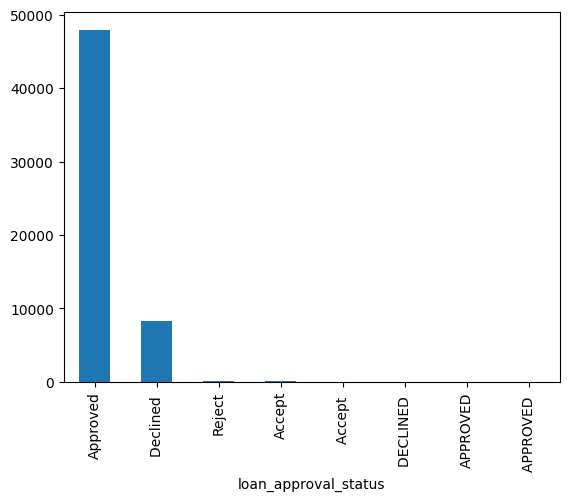

In [38]:
# check if distribution is normal


data_frame['loan_approval_status'].value_counts().plot(kind='bar')

<Axes: xlabel='loan_approval_status'>

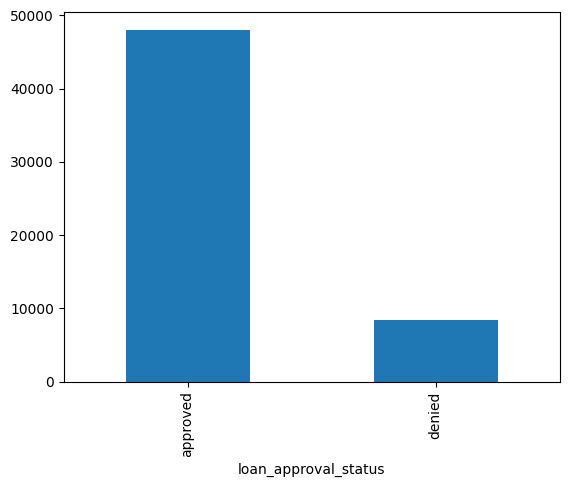

In [40]:
# clean categorical data, make sure there is only 2 categories, approved or declined
# code reuse session 1: #23

data_frame['loan_approval_status'] = data_frame['loan_approval_status'].str.lower().str.strip()
mapping = {
    'approved': 'approved',
    'accept': 'approved',
    'accept.': 'approved',
    'approved ': 'approved',

    'declined': 'denied',
    'rejected': 'denied',
    'reject': 'denied',
    'declined ': 'denied'
}

data_frame['loan_approval_status'] = data_frame['loan_approval_status'].replace(mapping)
data_frame['loan_approval_status'].value_counts().plot(kind='bar')

In [25]:
# fill in meaningful variables with median

data_frame['income'].fillna(data_frame['income'].median(), inplace=True)

/tmp/ipykernel_9527/3576525804.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [26]:
data_frame['employment_length'].fillna(data_frame['employment_length'].median(), inplace=True)

/tmp/ipykernel_9527/171149652.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [27]:
data_frame['loan_interest_rate'].fillna(data_frame['loan_interest_rate'].median(), inplace=True)

/tmp/ipykernel_9527/1529370730.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [28]:
data_frame['payment_default_on_file'].fillna(data_frame['payment_default_on_file'].mode()[0], inplace=True)

/tmp/ipykernel_9527/2803563897.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [29]:
data_frame['age'].fillna(data_frame['age'].median(), inplace=True)

/tmp/ipykernel_9527/3823196460.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [30]:
data_frame['loan_approval_status'].fillna(data_frame['loan_approval_status'].mode()[0], inplace=True)

/tmp/ipykernel_9527/4082153865.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [31]:
data_frame['credit_application_acceptance'].fillna(data_frame['credit_application_acceptance'].mode()[0], inplace=True)

/tmp/ipykernel_9527/1160633769.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [32]:
# see that missing data is now 0% for all categories
data_frame.isnull().sum()/len(data_frame)*100

,0
age,0.0
education_qualifications,0.0
income,0.0
home_ownership,0.0
employment_length,0.0
loan_intent,0.0
loan_amount,0.0
loan_interest_rate,0.0
loan_income_ratio,0.0
payment_default_on_file,0.0


In [39]:
# save cleaned loan approval data

cleaned_loan_approval_data = data_frame.to_csv('/content/drive/MyDrive/data science/cleaned_loan_approval_data.csv')